In [1]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [2]:
KM = KMeans(n_clusters=3, max_iter=300, random_state=0)
KM.fit(iris_df) # 훈련/테스트 분할 X
KM.labels_ #각 데이터가 속한 군집 번호

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [ ]:
iris_df['target'] = iris.target #실제값
iris_df['cluster'] = KM.labels_ #모델이 정한 군집번호
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1


타겟이 0인데, 군집은 1이라고 해서 이게 틀린것은 아님. (라벨이 다르게 설정된 것 일수도 있으니,,)

In [ ]:
iris_df.groupby(['target', 'cluster'])['sepal_length'].count()

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

군집의 평가 : 실루엣계수

In [17]:
from sklearn.metrics import silhouette_score, silhouette_samples
iris_df['silhouette_coeff'] = silhouette_samples(iris.data,iris_df['cluster'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797


In [18]:
silhouette_score(iris.data, iris_df['cluster'])

0.5511916046195919

In [20]:
score_sample = silhouette_samples(iris.data, iris_df['cluster'])
score_sample

array([ 0.85258191,  0.8149163 ,  0.82879659,  0.80435199,  0.84891774,
        0.7477614 ,  0.82109757,  0.8534934 ,  0.75127806,  0.82475199,
        0.80269525,  0.83540396,  0.80996716,  0.74535637,  0.70224038,
        0.64338856,  0.77526857,  0.85063272,  0.70636742,  0.81987458,
        0.78364122,  0.82546665,  0.79244412,  0.79345251,  0.77426479,
        0.79799564,  0.83296108,  0.84162136,  0.84325046,  0.81723402,
        0.8145665 ,  0.79849826,  0.76227879,  0.72184605,  0.82822866,
        0.83179477,  0.79374024,  0.84148042,  0.76779363,  0.84992603,
        0.84902387,  0.63767419,  0.78589195,  0.79963167,  0.74629437,
        0.80915172,  0.81295565,  0.81844011,  0.81783314,  0.85168255,
       -0.02672203,  0.36827154,  0.08489767,  0.59610609,  0.35669884,
        0.59416206,  0.27019063,  0.27245453,  0.32755642,  0.58167084,
        0.38107057,  0.58665651,  0.55085685,  0.47851679,  0.56757079,
        0.30479553,  0.5596951 ,  0.61137194,  0.46029717,  0.61

실루엣 계수 시각화

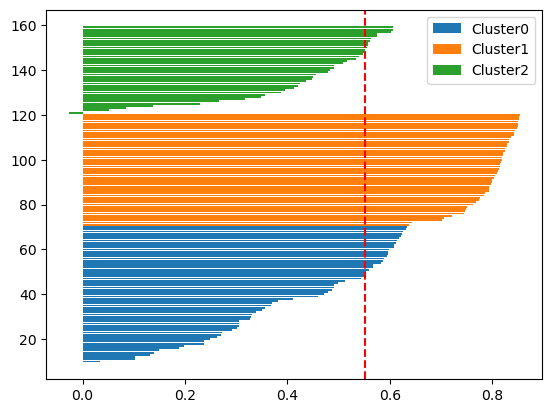

In [31]:
import matplotlib.pyplot as plt
y_lower = 10

for i in range(3):
  cluster_i = score_sample[iris_df['cluster'] == i]
  cluster_i.sort()
  y_upper = y_lower + len(cluster_i)
  plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
  y_lower = y_upper
  
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--')
plt.legend()
plt.show()

k의 값을 조정
데이터 스케일링

# k 값의 선택을 위한 스크리 차트

In [33]:
scree_df = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
sse_values = []
k_values = range(1,11)
for k in k_values :
  kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0)
  kmeans.fit(scree_df)
  sse_values.append(kmeans.inertia_)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

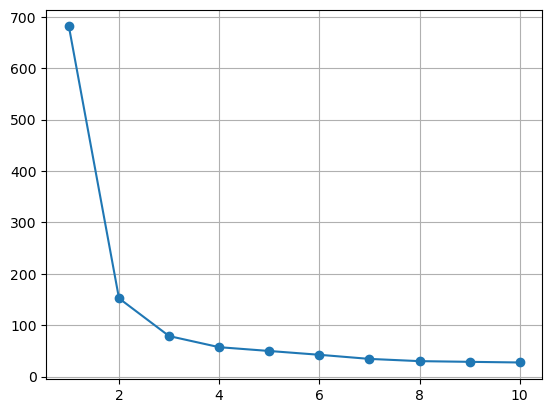

In [38]:
plt.plot(k_values, sse_values, marker='o')
plt.grid()
plt.show()

# iris_df의 차원축소

In [39]:
from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(iris.data)
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648]


In [42]:
iris_df['pca_x'] = X_pca[:,0]
iris_df['pca_y'] = X_pca[:,1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


In [41]:
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

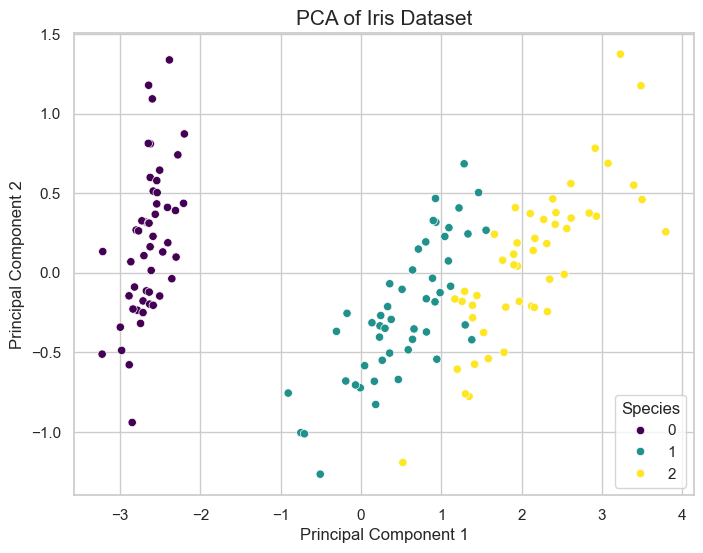

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 그래프 스타일 설정
sns.set_theme(style="whitegrid")

# 2. 산점도 그리기
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    x='pca_x', 
    y='pca_y', 
    hue='target', # 'target' 열이 있다면 그룹별로 색상이 지정됩니다.
    data=iris_df, 
    palette='viridis' # 색상 테마 설정
)

# 3. 그래프 제목 및 라벨 추가
plt.title('PCA of Iris Dataset', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Species')

# 4. 그래프 출력
plt.show()

iris_df 피처를 스케일링

In [45]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. 컬럼명을 모를 때는 위치(iloc)를 사용합니다.
# 마지막 열이 'target'이라고 가정하고, 그 전까지의 모든 열을 선택합니다.
x = iris_df.iloc[:, :-1] 

# 2. StandardScaler 적용
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 3. 결과를 데이터프레임으로 변환
# 기존 컬럼명을 그대로 가져와서 사용합니다.
iris_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)

# 4. 타겟 열 다시 합치기 (마지막 열)
target_column_name = iris_df.columns[-1]
iris_scaled_df[target_column_name] = iris_df[target_column_name].values

print("--- 컬럼 위치 기반 스케일링 완료 ---")
print(iris_scaled_df.head())

--- 컬럼 위치 기반 스케일링 완료 ---
   sepal_length  sepal_width  petal_length  petal_width    target   cluster  \
0     -0.900681     1.019004     -1.340227    -1.315444 -1.224745  0.182599   
1     -1.143017    -0.131979     -1.340227    -1.315444 -1.224745  0.182599   
2     -1.385353     0.328414     -1.397064    -1.315444 -1.224745  0.182599   
3     -1.506521     0.098217     -1.283389    -1.315444 -1.224745  0.182599   
4     -1.021849     1.249201     -1.340227    -1.315444 -1.224745  0.182599   

   silhouette_coeff     pca_x     pca_y  
0          1.358329 -1.309711  0.319397  
1          1.188575 -1.324357 -0.177001  
2          1.251132 -1.409674 -0.144949  
3          1.140963 -1.339582 -0.318299  
4          1.341815 -1.331469  0.326755  


주성분분석 2

In [46]:
# 1. PCA 객체 생성 (주성분 개수 2개)
pca = PCA(n_components=2)

# 2. 스케일링된 데이터(x_scaled)를 사용하여 PCA 수행
# 이전 단계에서 만든 x_scaled를 그대로 넣습니다.
pca_values = pca.fit_transform(x_scaled)

# 3. PCA 결과를 데이터프레임으로 정리
pca_df = pd.DataFrame(data=pca_values, columns=['pca_x', 'pca_y'])

# 4. 기존 데이터의 타겟(레이블) 정보를 다시 합치기 (시각화 용도)
# iris_df의 마지막 열이 타겟이라고 가정합니다.
pca_df['target'] = iris_df.iloc[:, -1].values

print("--- PCA 변환 완료 (처음 5행) ---")
print(pca_df.head())

# 5. 각 주성분이 설명하는 분산 비율 출력
print(f"\n설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"전체 설명력: {sum(pca.explained_variance_ratio_):.2%}")

--- PCA 변환 완료 (처음 5행) ---
      pca_x     pca_y    target
0 -3.152120  0.710720  0.319397
1 -2.970722 -0.083819 -0.177001
2 -3.230879  0.139873 -0.144949
3 -3.116799 -0.053567 -0.318299
4 -3.245118  0.811202  0.326755

설명된 분산 비율: [0.68099775 0.19236841]
전체 설명력: 87.34%


2개의 주성분 설명력 확인

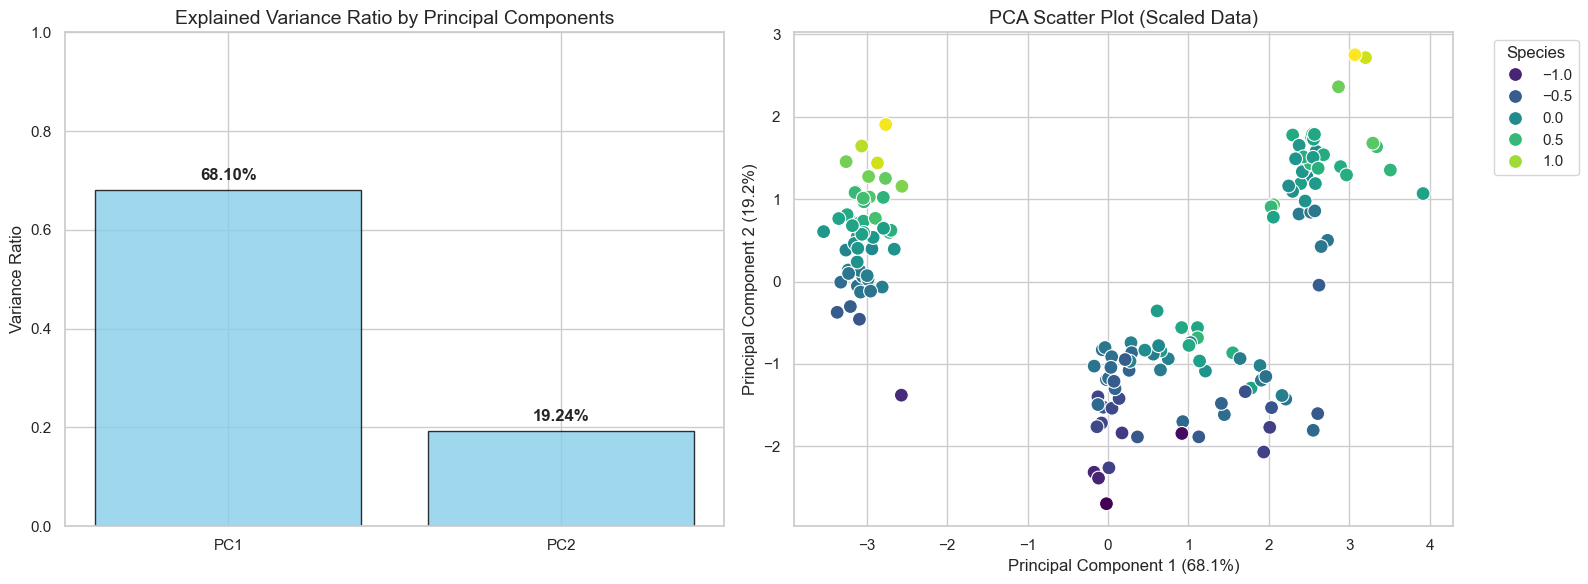

In [47]:
# 1. 그래프 설정 (1행 2열 구조)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- [좌측: 주성분별 기여도 (Explained Variance Ratio)] ---
pc_labels = ['PC1', 'PC2']
ax[0].bar(pc_labels, pca.explained_variance_ratio_, color='skyblue', edgecolor='black', alpha=0.8)
ax[0].set_title('Explained Variance Ratio by Principal Components', fontsize=14)
ax[0].set_ylabel('Variance Ratio')
ax[0].set_ylim(0, 1) # 비율이므로 0~1 사이로 고정

# 막대 위에 수치 표시
for i, v in enumerate(pca.explained_variance_ratio_):
    ax[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')


# --- [우측: PCA 산점도 (Scatter Plot)] ---
# pca_df에는 이미 'pca_x', 'pca_y', 'target'이 포함되어 있다고 가정합니다.
sns.scatterplot(
    x='pca_x', 
    y='pca_y', 
    hue='target', 
    data=pca_df, 
    palette='viridis', 
    s=100, # 점 크기
    ax=ax[1]
)
ax[1].set_title('PCA Scatter Plot (Scaled Data)', fontsize=14)
ax[1].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})')
ax[1].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})')
ax[1].legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()